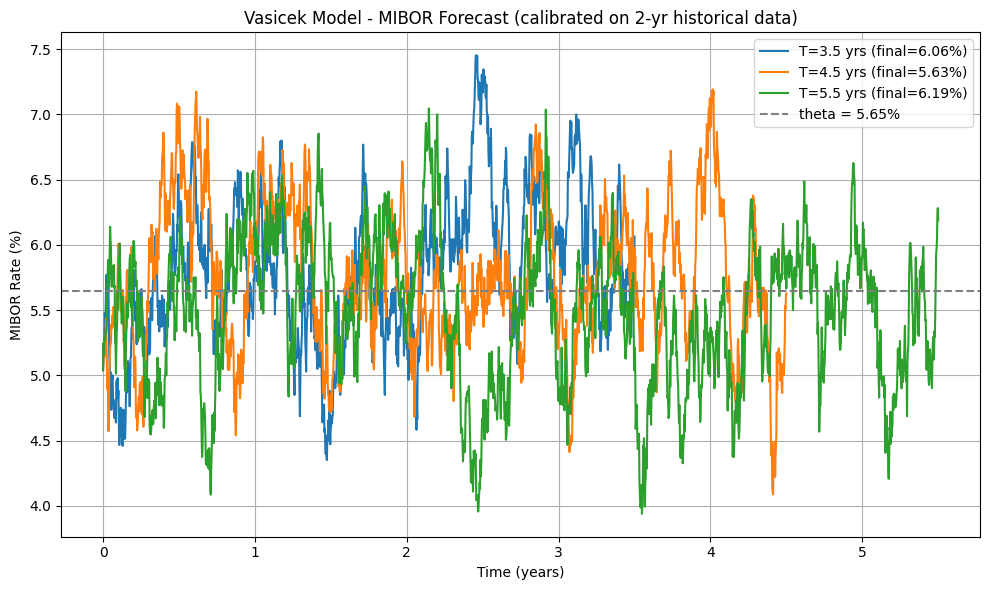

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1: Parameters (taken from MIBOR_Rate_Vasicek_Model_Calculation.xlsx)
# These were calculated in Excel using 2 years of daily MIBOR data:
#   kappa = -slope / dt
#   theta = -intercept / slope
#   sigma = STDEV(residuals) / sqrt(dt)
# ---------------------------------------------------------
kappa = 12.3340778587752     # speed of mean reversion
theta = 0.0564993739114914   # long-term mean level (5.65%)
sigma = 0.0277094030067748   # volatility (2.77%)
dt = 1 / 365                 # daily time step
r0 = 0.0504                  # last observed MIBOR rate (5.04%)

np.random.seed(42)           # fixes randomness so the chart is reproducible

# ---------------------------------------------------------
# STEP 2: Function to simulate one Vasicek path up to time T (in years)
# ---------------------------------------------------------
def simulate_vasicek(r0, kappa, theta, sigma, dt, T):
    n_steps = int(T / dt)                     # number of daily steps to reach T years
    rates = np.zeros(n_steps + 1)
    rates[0] = r0
    for i in range(n_steps):
        dW = np.random.normal() * np.sqrt(dt)                     # random shock
        dr = kappa * (theta - rates[i]) * dt + sigma * dW         # Vasicek SDE
        rates[i + 1] = rates[i] + dr
    return rates

# ---------------------------------------------------------
# STEP 3: Simulate for each required horizon
# ---------------------------------------------------------
horizons = [3.5, 4.5, 5.5]   # prediction years

plt.figure(figsize=(10, 6))
for T in horizons:
    path = simulate_vasicek(r0, kappa, theta, sigma, dt, T)
    t_axis = np.linspace(0, T, len(path))
    plt.plot(t_axis, path * 100, label=f"T={T} yrs (final={path[-1]*100:.2f}%)")

# Reference line for the long-term mean (theta)
plt.axhline(theta * 100, color="gray", linestyle="--", label=f"theta = {theta*100:.2f}%")

# ---------------------------------------------------------
# STEP 4: Plot formatting
# ---------------------------------------------------------
plt.xlabel("Time (years)")
plt.ylabel("MIBOR Rate (%)")
plt.title("Vasicek Model - MIBOR Forecast (calibrated on 2-yr historical data)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

